In [29]:
from langgraph.graph import StateGraph, START, END
from langchain_mistralai import ChatMistralAI
from typing import TypedDict
from dotenv import load_dotenv

In [30]:
load_dotenv()

True

In [31]:
model = ChatMistralAI()

In [54]:
# create a state

class LLMState(TypedDict):
    topic:str
    outline:str
    content:str
    evaluation:str
    

In [49]:
def gen_outline(state:LLMState) -> LLMState:
    # extract question 
    topic = state['topic']

    # form a prompt 
    prompt = f"Generate a detailed outline for this tp]opic - {topic}"

    # call llm
    answer = model.invoke(prompt).content

    # update the answer in state
    state["outline"] = answer

    # return the state
    return state


In [50]:
def write_blog(state:LLMState) -> LLMState:
    outline = state["outline"]

    prompt = f"Write a blog for this outline - {outline}"

    content = model.invoke(prompt).content

    state["content"] = content

    return state

In [55]:
def evaluate(state:LLMState) -> LLMState:
    outline = state['outline']
    content = state["content"]

    prompt = f"Based on my this outline, rate the blog from 1 to 10, outline - {outline}, blog - {content}"

    output = model.invoke(prompt).content

    state['evaluation'] = output

    return state

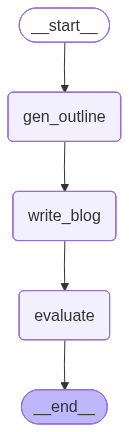

In [56]:
# create a graph
graph = StateGraph(LLMState)

# add nodes
graph.add_node("gen_outline", gen_outline)
graph.add_node("write_blog", write_blog)
graph.add_node("evaluate", evaluate)
# add edges
graph.add_edge(START, "gen_outline")
graph.add_edge("gen_outline", "write_blog")
graph.add_edge("write_blog", "evaluate")
graph.add_edge("evaluate", END)

# compile
workflow = graph.compile()
workflow

In [57]:
# execute
initial_state = {"topic":"moon"}

final_state = workflow.invoke(initial_state)

print(final_state["evaluation"])

Your blog post is **exceptionally well-structured, informative, and engaging**—earning a **9.5/10**. Below is a detailed breakdown of its strengths and minor areas for improvement to help you refine it further.

---

### **Strengths (Why It Deserves a 9.5/10)**
1. **Comprehensive & Well-Organized**
   - Follows your outline **flawlessly**, covering every major aspect of the Moon (formation, exploration, mysteries, future).
   - Logical flow: Starts with an introduction, dives into science, explores history, and ends with forward-looking insights.
   - **Bonus:** The optional sections (mythology, pop culture) could be added as standalone posts.

2. **Scientifically Accurate & Up-to-Date**
   - Cites recent missions (Artemis, Chang’e, private sector involvement).
   - Balances **scientific rigor** with **accessible language**—ideal for both casual readers and space enthusiasts.
   - Correctly explains complex concepts (e.g., tidal locking, Giant Impact Hypothesis) without oversimplifying

In [58]:
print(final_state["outline"])

### **Detailed Outline: The Moon**

#### **I. Introduction**
   A. Brief Overview of the Moon
      - Definition and basic characteristics
      - Its significance in human history and culture
   B. Importance of Studying the Moon
      - Scientific, cultural, and exploratory value
   C. Overview of the Outline

---

#### **II. Formation and Origin of the Moon**
   A. The Giant Impact Hypothesis (Big Splash)
      - Theia collision theory
      - Evidence supporting this model
   B. Alternative Theories
      - Capture theory
      - Co-formation (sister planet) theory
      - Fission theory
   C. Timeline of the Moon’s Formation (~4.5 billion years ago)

---

#### **III. Physical Characteristics of the Moon**
   A. Size and Mass
      - Diameter (~3,474 km)
      - Mass (~1.2% of Earth's mass)
   B. Surface Features
      1. **Maria (Dark Regions)**
         - Basaltic plains formed by ancient volcanic activity
      2. **Highlands (Bright Regions)**
         - Ancient, heavily crater

In [59]:
print(final_state["content"])

# **The Moon: Earth’s Mysterious Companion and Gateway to the Cosmos**

## **I. Introduction**

The Moon, Earth’s only natural satellite, has captivated humanity for millennia. Shining brightly in the night sky, it influences tides, shapes cultures, and serves as a celestial timekeeper. But beyond its poetic allure, the Moon is a scientific treasure—a frozen record of the solar system’s early history and a potential stepping stone for humanity’s expansion into space.

### **A. Brief Overview of the Moon**
- **Definition & Basic Characteristics:** The Moon is a rocky, airless world with a diameter of about 3,474 km (2,159 miles)—roughly one-fourth the size of Earth. Its gravity is only 1/6th of Earth’s, making it a low-gravity environment.
- **Significance in History & Culture:** From ancient myths to modern space missions, the Moon has been a symbol of mystery, divinity, and exploration. It features in folklore, religious texts, and even inspired the first human footsteps on another wo